In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [78]:
df = pd.read_csv('insurance.csv')


# EDA

In [79]:
# df.head()
# df.shape
# df.info()
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [80]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [81]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

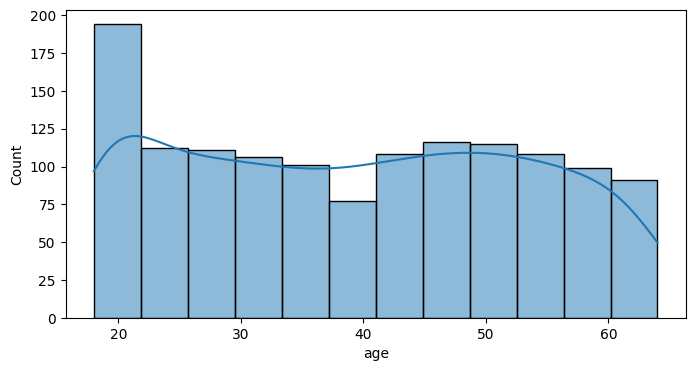

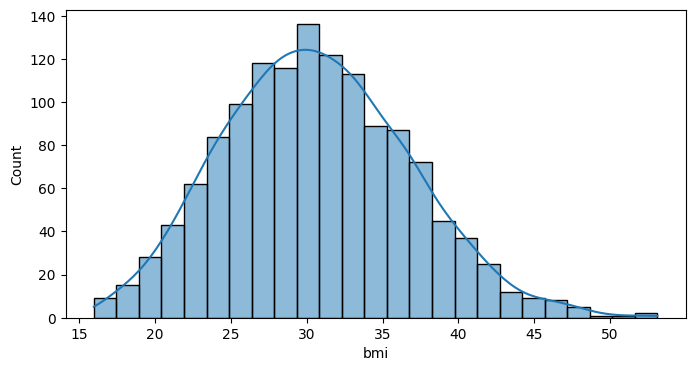

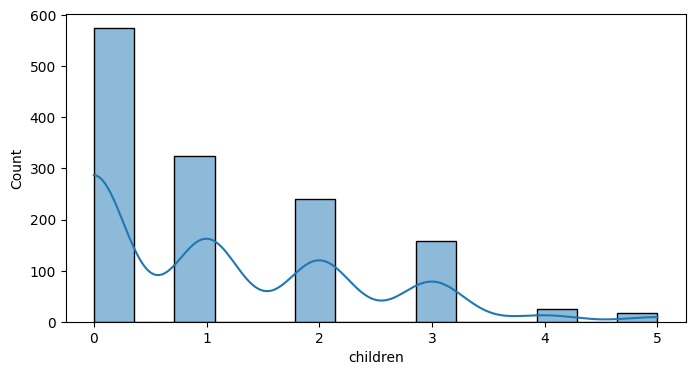

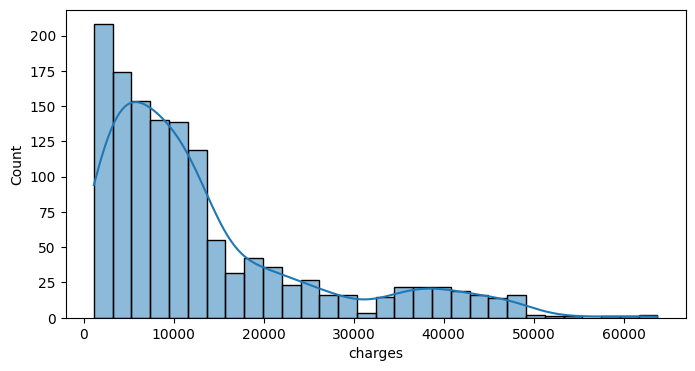

In [82]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)


<Axes: xlabel='children', ylabel='count'>

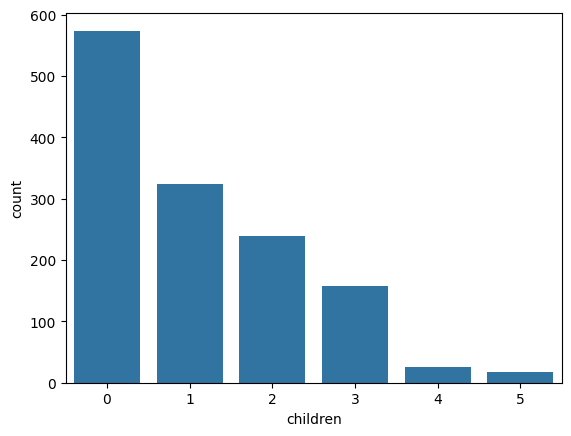

In [83]:
sns.countplot(x= df['children'])

<Axes: xlabel='sex', ylabel='count'>

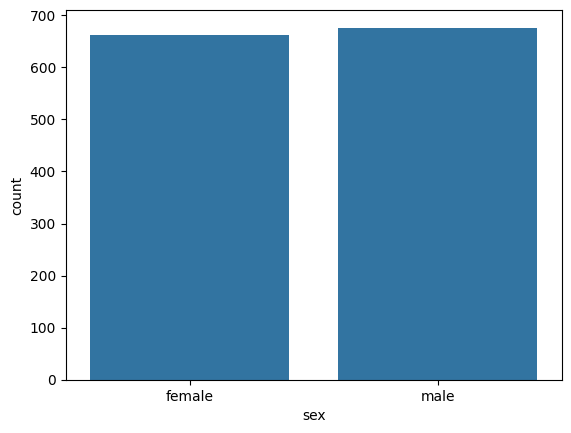

In [84]:

sns.countplot(x= df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

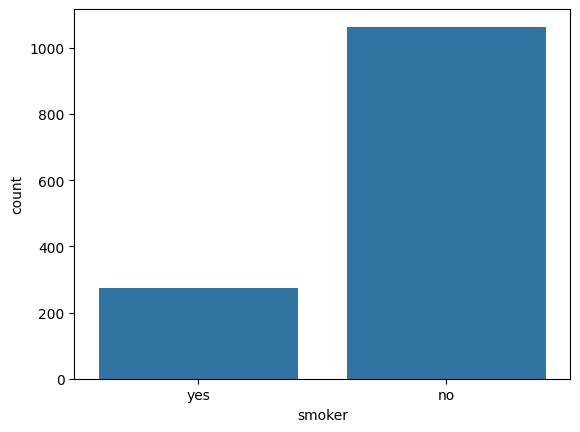

In [85]:
sns.countplot(x=df['smoker'])

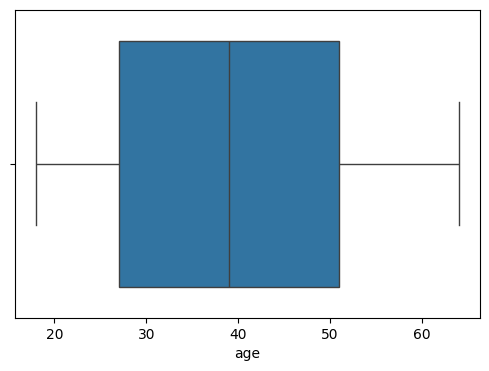

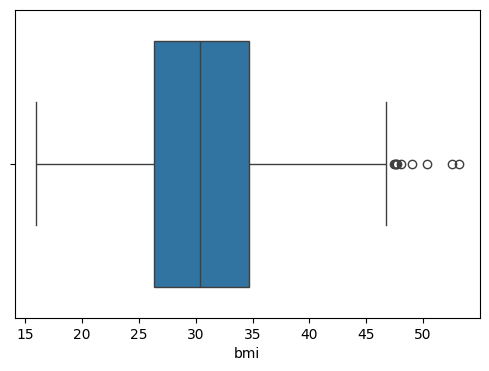

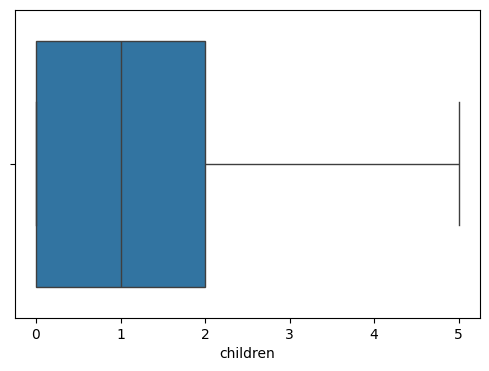

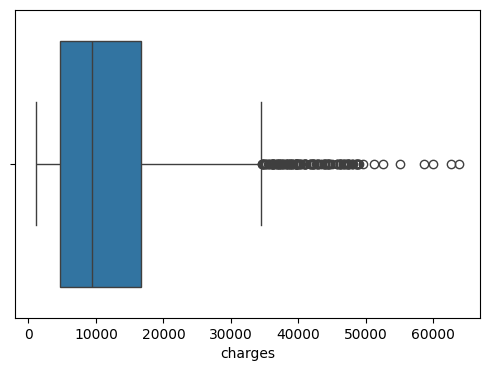

In [86]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])

<Axes: >

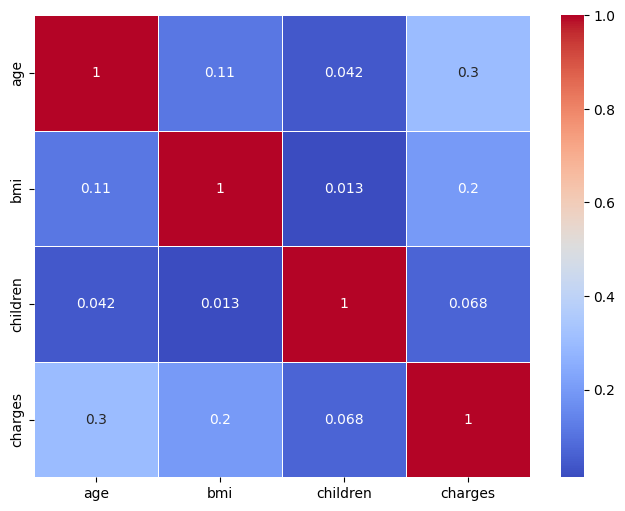

In [87]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)

# DATA CLEANING AND PREPROCESSING

In [88]:
df_cleaned = df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [89]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape  

(1337, 7)

In [90]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [91]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [92]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male": 0, "female": 1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [93]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [94]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no": 0, "yes": 1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [95]:
df_cleaned.rename(columns={'sex': 'is_female',
                           'smoker': 'is_smoker'}, inplace=True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [96]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [97]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [98]:
df_cleaned.head()


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [99]:
df_cleaned = df_cleaned.astype(int)

In [100]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


# FEATURE ENGINEERING AND EXTRACTION

<Axes: xlabel='bmi', ylabel='Count'>

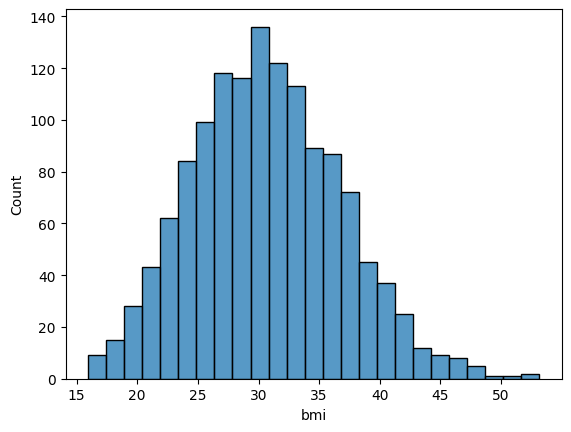

In [101]:
sns.histplot(df['bmi'])

In [102]:
df_cleaned['dmi_category'] = pd.cut(df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [103]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,dmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [104]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['dmi_category'], drop_first=True)

In [105]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,dmi_category_Normal,dmi_category_Overweight,dmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [106]:
df_cleaned = df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,dmi_category_Normal,dmi_category_Overweight,dmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [107]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'dmi_category_Normal', 'dmi_category_Overweight', 'dmi_category_Obese'],
      dtype='str')

In [108]:
from sklearn.preprocessing import StandardScaler
colm = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[colm] = scaler.fit_transform(df_cleaned[colm])

In [109]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,dmi_category_Normal,dmi_category_Overweight,dmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [110]:
from scipy.stats import pearsonr

selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker', 
                    'region_northwest', 'region_southeast', 'region_southwest', 
                    'dmi_category_Normal', 'dmi_category_Overweight', 'dmi_category_Obese']

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0] 
    for feature in selected_features
}

correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlations_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,dmi_category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,dmi_category_Normal,-0.104042


In [111]:
correlations_df

,Feature,Pearson Correlation
0,age,0.298309
1,bmi,0.196236
2,children,0.067390
3,is_female,-0.058046
4,is_smoker,0.787234
5,region_northwest,-0.038695
6,region_southeast,0.073577
7,region_southwest,-0.043637
8,dmi_category_Normal,-0.104042
9,dmi_category_Overweight,-0.120601


In [112]:
cat_features = ['is_female', 'is_smoker', 
                'region_northwest', 'region_southeast', 'region_southwest', 
                'dmi_category_Normal', 'dmi_category_Overweight', 'dmi_category_Obese'
                ]

In [113]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (keep Feature)' if p_val < alpha else 'Accept Null (drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2, 
        'p_value': p_val, 
        'decision': decision
    }

chi2_results_df = pd.DataFrame(chi2_results).T
chi2_results_df.sort_values(by='p_value')
chi2_results_df

,chi2_statistic,p_value,decision
is_female,10.258784,0.01649,Reject Null (keep Feature)
is_smoker,848.219178,0.0,Reject Null (keep Feature)
region_northwest,1.13424,0.768815,Accept Null (drop Feature)
region_southeast,15.998167,0.001135,Reject Null (keep Feature)
region_southwest,5.091893,0.165191,Accept Null (drop Feature)
dmi_category_Normal,3.708088,0.29476,Accept Null (drop Feature)
dmi_category_Overweight,4.25149,0.235557,Accept Null (drop Feature)
dmi_category_Obese,8.515711,0.036473,Reject Null (keep Feature)


In [116]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_northwest','dmi_category_Obese']]


In [117]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_northwest,dmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
